# **Module_3: Fibrosis**

## **Team Members:** Theresa Breckley and Mohamed Elfaki

## **Project Title:**
*(Fill in)*



## **Project Goal:**

This project aims to quantify how fibrotic tissue varies across lung depth using segmented image data, and to evaluate how well interpolation methods can estimate fibrosis at unmeasured depths. Additionally, the project explores whether fibrosis is uniformly distributed and assesses the reliability of predictions based on limited data.

### **Project Questions:**
* How does the percentage of fibrotic tissue change with tissue depth?
* Is fibrosis distributed uniformly through lung tissue?
* Can interpolation accuraltely estimate fibrosis at unmeasured depths?
* How reliable are predictions based on limited or sparse data?

## **Disease Background:** 

### **Prevalence and Incidence**

Idiopathic Pulmonary Fibrosis (IPF) is a chronic and progressive interstitial lung disease characterized by irreversible scarring of lung tissue. It is considered relatively rare, with an estimated prevalence of approximately 13–20 cases per 100,000 individuals in the United States. The disease primarily affects older adults, most commonly those over the age of 60, and occurs more frequently in men than in women. Despite its relatively low prevalence, IPF carries a poor prognosis, with a median survival time of only 3–5 years following diagnosis.

### **Risk Factors**

Several risk factors are associated with the development of IPF, although the exact cause remains unknown. Age is the most significant factor, with incidence increasing substantially in older populations. A history of smoking is strongly linked to increased risk, as are environmental and occupational exposures such as metal dust, wood dust, and other airborne pollutants. Genetic predisposition also plays a role, particularly in individuals with family histories of pulmonary fibrosis or mutations affecting surfactant production and telomere maintenance. Additionally, conditions like gastroesophageal reflux disease (GERD) may contribute to repeated lung injury, further increasing risk.

### **Symptoms**

The symptoms of IPF are typically gradual in onset and worsen over time. The most common symptom is progressive shortness of breath, especially during physical activity, which reflects declining lung function. Patients also frequently experience a persistent dry cough, fatigue, and general weakness. As the disease advances, unintended weight loss may occur, and some individuals develop digital clubbing, a condition characterized by the enlargement of the fingertips. These symptoms significantly impact quality of life and become more severe as fibrosis progresses.

### **Standard of Care/Treatment**
    
There is currently no cure for IPF, and treatment focuses on slowing disease progression and managing symptoms. Two primary antifibrotic medications, Pirfenidone and Nintedanib, are commonly prescribed to reduce the rate of lung function decline. Supplemental oxygen therapy is often used to address low blood oxygen levels, while pulmonary rehabilitation programs help improve physical endurance and overall quality of life. For eligible patients, lung transplantation remains the only definitive treatment option. In addition to these interventions, supportive care is essential to manage symptoms and improve patient comfort.

### **Biological Mechanisms (Pathophysiology)**

IPF is driven by repeated micro-injury to the alveolar epithelium, particularly affecting type I and type II pneumocytes, which are essential for gas exchange and surfactant production. Instead of normal tissue repair, the lungs undergo an abnormal healing response characterized by excessive activation of fibroblasts. These cells produce large amounts of collagen and extracellular matrix, leading to thickening and stiffening of lung tissue. This fibrotic remodeling disrupts the alveolar-capillary interface, impairing oxygen diffusion into the bloodstream. As fibrosis progresses, lung compliance decreases, making it more difficult for the lungs to expand, ultimately leading to reduced oxygenation and respiratory failure.

## **Data-Set:**

The dataset used in this project consists of unpublished biomedical imaging data collected by the Peirce-Cottler Lab (Department of Biomedical Engineering) and the Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. It includes microscopy images of lung tissue samples along with corresponding segmentation masks that isolate regions of interest, such as fibrotic tissue. Each image is associated with a depth value, indicating its position within the tissue, allowing for analysis of spatial variation in fibrosis. The data are organized through structured filenames that encode information about sample region, imaging conditions, and acquisition order, enabling consistent pairing of images, masks, and metadata.

The primary variables analyzed are derived from image processing, including pixel intensity values and the proportion of masked regions, which serve as indicators of tissue structure and fibrosis extent. These values are measured in pixel units, with comparisons made relative across samples. Preprocessing steps include loading image–mask pairs, converting images to numerical arrays, and applying masks to isolate relevant regions. The analysis assumes that masks accurately represent areas of interest and that image quality and depth measurements are consistent. Limitations of the dataset include its relatively small size, lack of clinical metadata, potential variability in imaging conditions, and possible inaccuracies in segmentation, all of which may impact the generalizability and precision of results.

## **Data Analyis:** 


#### **Fibrotic Tissue at Different Depths**

To investigate how fibrosis changes throughout lung tissue, segmented binary images were analyzed at multiple depths. In these images, white pixels represent fibrotic tissue, while black pixels represent non-fibrotic regions.

For each image, the number of white and black pixels was calculated and used to determine the percentage of fibrotic tissue. These values were then paired with their corresponding imaging depths to create a dataset describing fibrosis as a function of depth.

By analyzing this relationship, we aim to determine whether fibrosis is evenly distributed throughout the tissue or varies across different regions.

                        Filename  Depth (microns)  White pixels  Black pixels  \
0  MASK_SK658 Llobe ch010039.jpg               15         21648       4172656   
1  MASK_SK658 Llobe ch010021.jpg               30         23900       4170404   
2  MASK_SK658 Llobe ch010017.jpg               45         27561       4166743   
3  MASK_SK658 Llobe ch010036.jpg               55         29677       4164627   
4  MASK_SK658 Llobe ch010019.jpg               60         31331       4162973   

   White percent  
0       0.516129  
1       0.569820  
2       0.657105  
3       0.707555  
4       0.746989  
Pixel count check passed: True


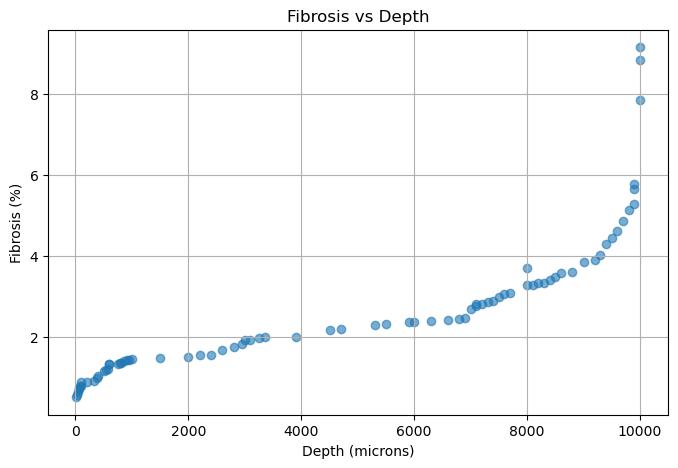

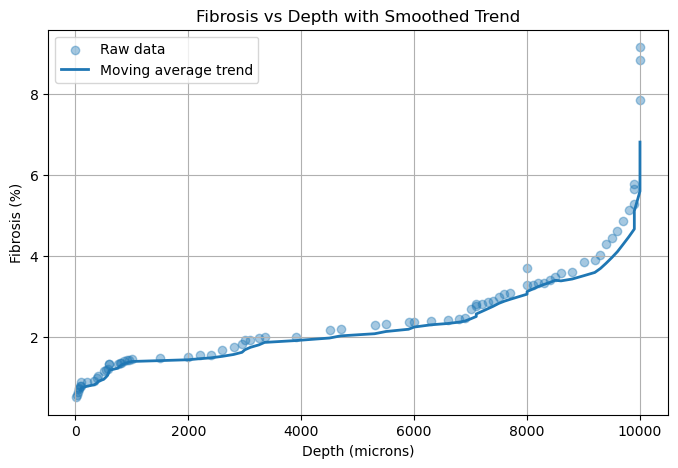

In [6]:
# ---------------------------
# Import Libraries
# ---------------------------
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---------------------------
# Load CSV with filenames + depths
# ---------------------------
csv_path = r"C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\Filenames and Depths for Students.csv"
df_files = pd.read_csv(csv_path)


filename_col = df_files.columns[0]
depth_col = df_files.columns[1]

# ---------------------------
# Full path to image folder
# ---------------------------
image_folder = r"C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\images"

# ---------------------------
# Function to calculate pixel data
# ---------------------------
def calculate_fibrosis(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Warning: Could not load {image_path}")
        return None, None, None

    # Binary threshold
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Pixel counts
    white_pixels = np.sum(binary == 255)
    total_pixels = binary.size
    black_pixels = total_pixels - white_pixels

    # Percentage
    white_percent = (white_pixels / total_pixels) * 100

    return white_pixels, black_pixels, white_percent

# ---------------------------
# Process all images
# ---------------------------
filenames_used = []
depths = []
white_values = []
black_values = []
percent_values = []

for _, row in df_files.iterrows():
    filename = str(row[filename_col]).strip()

    # Remove extra folder text if present
    filename = filename.replace("images/", "").replace("images\\", "")

    depth = row[depth_col]

    image_path = os.path.join(image_folder, filename)

    if not os.path.exists(image_path):
        print("Missing file:", image_path)
        continue

    white, black, percent = calculate_fibrosis(image_path)

    if white is not None:
        filenames_used.append(filename)
        depths.append(depth)
        white_values.append(white)
        black_values.append(black)
        percent_values.append(percent)

# ---------------------------
# Create DataFrame
# ---------------------------
results_df = pd.DataFrame({
    "Filename": filenames_used,
    "Depth (microns)": depths,
    "White pixels": white_values,
    "Black pixels": black_values,
    "White percent": percent_values
})

# Convert depth to numeric and sort
results_df["Depth (microns)"] = pd.to_numeric(results_df["Depth (microns)"], errors="coerce")
results_df = results_df.dropna()
results_df = results_df.sort_values(by="Depth (microns)")

# ---------------------------
# Save CSV file
# ---------------------------
output_csv = r"C:\Users\15712\OneDrive - University of Virginia\Comp Mod 3\Module-3-Fibrosisb-breckley_elfaki\fibrosis_vs_depth_results.csv"
results_df.to_csv(output_csv, index=False)

print(results_df.head())

# ---------------------------
# Verification check
# ---------------------------
total_pixels_check = np.array(white_values) + np.array(black_values)
print("Pixel count check passed:", np.all(total_pixels_check > 0))

# ---------------------------
# Plot RAW data
# ---------------------------
x = results_df["Depth (microns)"].values
y = results_df["White percent"].values

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("Depth (microns)")
plt.ylabel("Fibrosis (%)")
plt.title("Fibrosis vs Depth")
plt.grid(True)
plt.show()

# ---------------------------
# Moving Average Trend Line
# ---------------------------
# Sort data (just to be safe)
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

# Moving average
window = 7
y_smooth = np.convolve(y_sorted, np.ones(window)/window, mode='valid')
x_smooth = x_sorted[window-1:]

plt.figure(figsize=(8, 5))
plt.scatter(x_sorted, y_sorted, alpha=0.4, label="Raw data")
plt.plot(x_smooth, y_smooth, linewidth=2, label="Moving average trend")
plt.xlabel("Depth (microns)")
plt.ylabel("Fibrosis (%)")
plt.title("Fibrosis vs Depth with Smoothed Trend")
plt.grid(True)
plt.legend()
plt.show()

def plot_zoom(x, y, xmin, xmax, title):
    mask = (x >= xmin) & (x <= xmax)
    
    x_zoom = x[mask]
    y_zoom = y[mask]
    
    if len(x_zoom) == 0:
        print(f"No data in range {xmin}-{xmax}")
        return
    
    
    plt.figure(figsize=(7,4))
    plt.scatter(x_zoom, y_zoom, alpha=0.7)
    plt.xlabel("Depth (microns)")
    plt.ylabel("Fibrosis (%)")
    plt.title(title)
    plt.grid(True)
    plt.show()

**Overall Trend Analysis**

The full dataset shows that the percentage of fibrotic tissue generally increases with depth. At shallow depths, fibrosis levels are relatively low, while deeper regions exhibit higher percentages of fibrotic tissue.

However, the relationship is not perfectly linear. Instead, the data suggests a gradual increase followed by a more rapid rise at greater depths. This indicates that fibrosis accumulation is not uniform and may become more severe in deeper regions of the tissue.

Additionally, some variability is observed within the data, suggesting that fibrosis is not evenly distributed even at similar depths.

### **Localized Analysis of Fibrosis by Depth**

To better understand how fibrosis behaves at different regions of the tissue, the data was divided into three depth ranges: shallow (0–2000 microns), mid-depth (2000–6000 microns), and deep (6000–10000 microns).

Examining these regions individually allows for a more detailed analysis of how fibrotic tissue changes across the lung and helps identify patterns that may not be visible in the full dataset.

#### **0-2000 Microns**

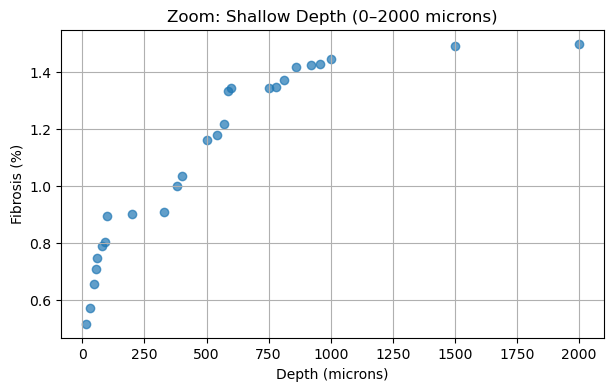

In [7]:
# Shallow region
plot_zoom(x, y, 0, 2000, "Zoom: Shallow Depth (0–2000 microns)")

The shallow region (0–2000 microns) shows relatively low fibrosis percentages, with values gradually increasing from approximately 0.5% to around 1.5%. The increase is steady, suggesting early-stage or less severe fibrotic involvement in these regions.

#### **2000-6000 Microns**

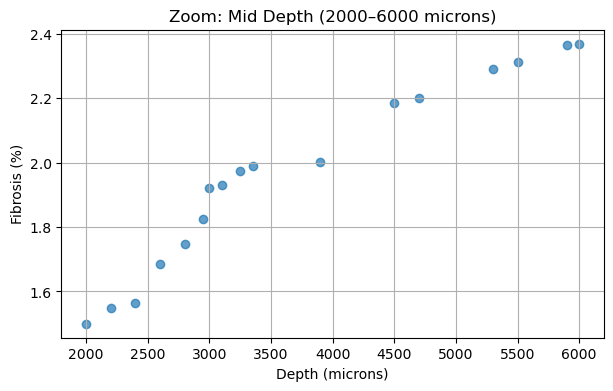

In [8]:
# Middle region
plot_zoom(x, y, 2000, 6000, "Zoom: Mid Depth (2000–6000 microns)")

In the mid-depth range (2000–6000 microns), fibrosis continues to increase at a moderate rate, reaching values around 2.3%. The trend remains relatively smooth, indicating a consistent progression of fibrosis through this portion of the tissue.

#### **6000-10000 Microns**

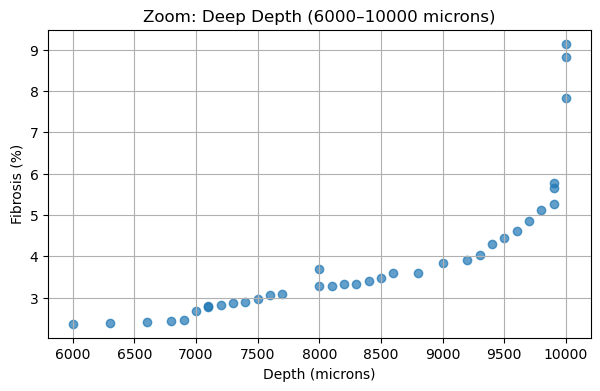

In [9]:
# Deep region
plot_zoom(x, y, 6000, 10000, "Zoom: Deep Depth (6000–10000 microns)")

In contrast, the deep region (6000–10000 microns) shows a more pronounced increase in fibrosis. While the lower end of this range begins near 2.5–3%, the upper depths exhibit a sharp rise, with some values exceeding 8–9%. This suggests that fibrosis becomes significantly more severe at greater depths.

Overall, these results indicate that fibrosis is not uniformly distributed throughout the lung tissue. Instead, fibrotic burden increases with depth and shows more rapid progression in deeper regions, highlighting the heterogeneous nature of the disease.

### **Interpolation:**

In [4]:
interpolate_depth = float(input("Enter the depth to interpolate (in microns): "))
interpolator = interp1d(depths, white_percents, kind="linear")
interpolated_percent = float(interpolator(interpolate_depth))

print(
    f"The interpolated point is at depth {interpolate_depth} microns "
    f"with white pixel percentage {interpolated_percent:.2f}%."
)

plt.figure(figsize=(8, 5))
plt.scatter(depths, white_percents, label="Original data")
plt.plot(depths, white_percents)
plt.scatter(interpolate_depth, interpolated_percent, color="red", s=80, label="Interpolated point")
plt.title("Depth vs Percentage of White Pixels with Interpolated Point")
plt.xlabel("Depth of image (microns)")
plt.ylabel("White pixels as % of total pixels")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'interp1d' is not defined

## **Verify and validate your analysis:** 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## **Conclusions and Ethical Implications:** 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## **Limitations and Future Work:**
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## **References:**
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*